# Sea Buckthorn Market Analytics & EDA

This notebook performs Exploratory Data Analysis (EDA) on the Sea buckthorn market dataset. It analyzes pricing, origins, health claims, and bioactives across various competitors.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load the dataset
df = pd.read_csv('data/seabuckthorn_market_data.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (150, 7)


,Brand,Product Name,Price ($),Origin,Health Claims,Bioactives,Source
0,Leh Berry,Leh Berry Sea buckthorn Juice,54.02,"Nubra Valley, Ladakh","Promotes skin health, Skin hydration, Menopaus...","Vitamin E, Vitamin A, Vitamin C, 180+ Bioactiv...",Generated based on prompt domain knowledge
1,Erbology,Erbology Sea buckthorn Juice,57.78,Himalayas (India),"Menopause support, Promotes skin health, Stres...","Vitamin E, Vitamin K, Vitamin A, Omega 3",Generated based on prompt domain knowledge
2,Wellsash/Biosash,Wellsash/Biosash Wonder Berry Capsules,29.65,Himalayas (India),"Promotes skin health, Immunity, Heart & Metabo...","Omega 7, 180+ Bioactives, Omega 9, Vitamin C",Generated based on prompt domain knowledge
3,Leh Berry,Leh Berry GI TAG Berry Powder,15.32,"Nubra Valley, Ladakh","Stress Relief, Gut Friendly, Cellular Hydration","Omega 9, Vitamin C, Vitamin K, Vitamin E, Omeg...",Generated based on prompt domain knowledge
4,SeabuckWonders,SeabuckWonders Wonder Berry Capsules,61.41,China,"Immunity, Stress Relief, Gut Friendly","Vitamin A, 180+ Bioactives, Vitamin C, Vitamin...",Generated based on prompt domain knowledge


## 1. Market Overview by Origin and Brand
Let's see the distribution of products based on their origin (e.g., Himalayas vs China) and by Brand.


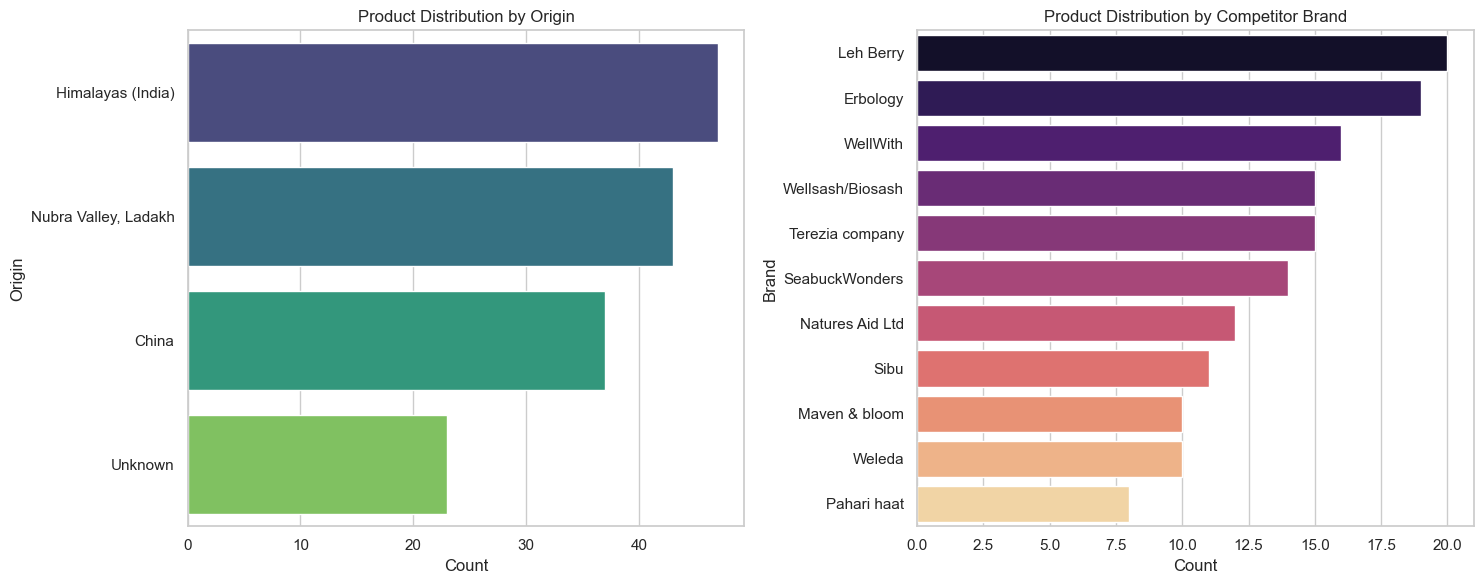

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(y='Origin', data=df, order=df['Origin'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Product Distribution by Origin')
axes[0].set_xlabel('Count')

sns.countplot(y='Brand', data=df, order=df['Brand'].value_counts().index, ax=axes[1], palette='magma')
axes[1].set_title('Product Distribution by Competitor Brand')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('data/market_overview.png')
plt.show()


## 2. Pricing Analysis
Analyzing the price distribution across different brands.


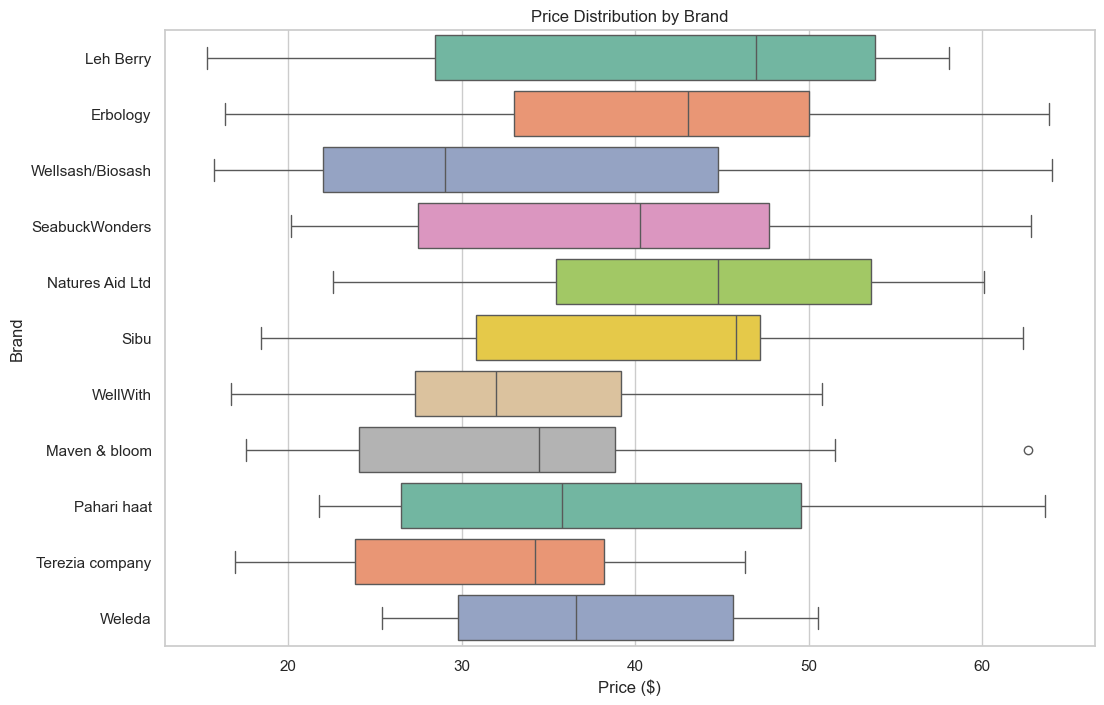

In [4]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Price ($)', y='Brand', data=df, palette='Set2')
plt.title('Price Distribution by Brand')
plt.savefig('data/pricing_analysis.png')
plt.show()


## 3. Health Claims & Bioactives Analysis
Sea buckthorn is known for its "180+ bioactives" and being an "Omega powerhouse". Let's analyze the frequency of these claims.


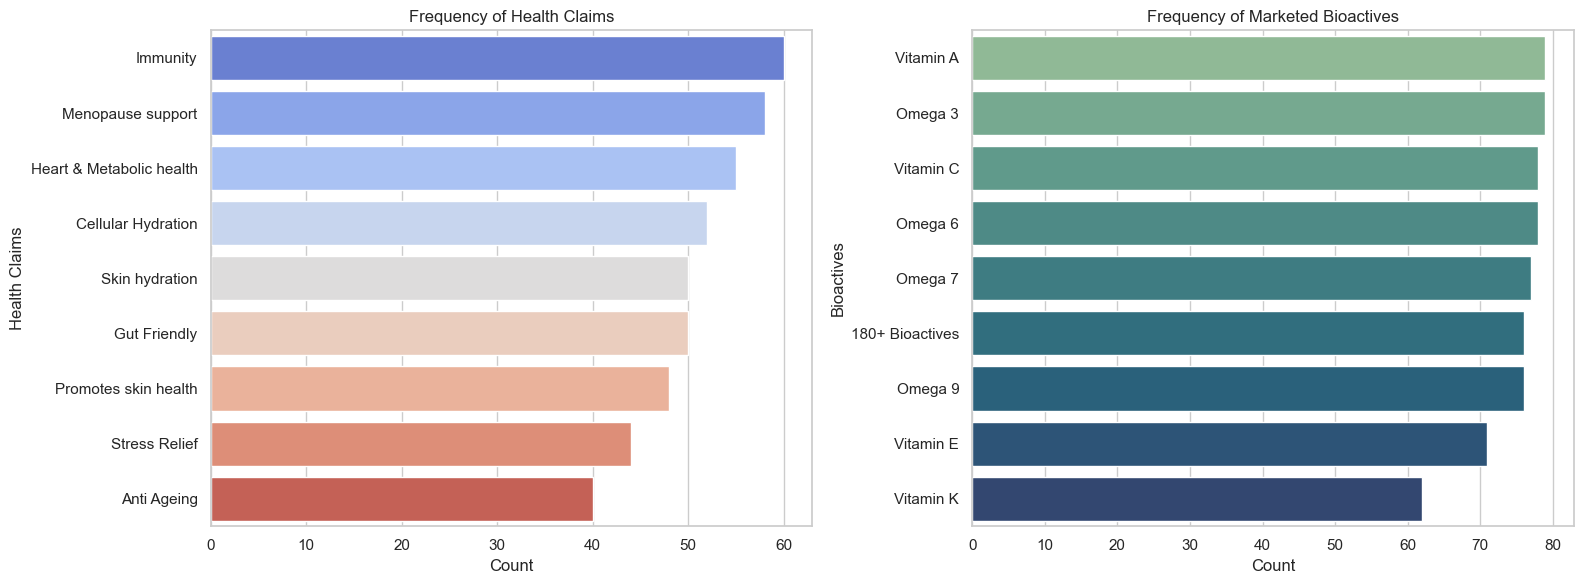

In [5]:
# Explode the comma-separated claims and bioactives
claims_series = df['Health Claims'].str.split(', ').explode()
bioactives_series = df['Bioactives'].str.split(', ').explode()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Claims
sns.countplot(y=claims_series, order=claims_series.value_counts().index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Frequency of Health Claims')
axes[0].set_xlabel('Count')

# Plot Bioactives
sns.countplot(y=bioactives_series, order=bioactives_series.value_counts().index, ax=axes[1], palette='crest')
axes[1].set_title('Frequency of Marketed Bioactives')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('data/claims_analysis.png')
plt.show()
